# Star Dataset Analysis

## Absolute Magnitude vs Spectral Class and Type

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the Dataset

In [3]:
df = pd.read_csv("../data/Stars.csv.xls")

## Research Question

Do these stars have higher average temperatures than the remaining stars, considering their brightness?

## First Look

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
 6   Type            240 non-null    int64  
dtypes: float64(3), int64(2), str(2)
memory usage: 13.3 KB


In [5]:
df.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0


## Step 1

First, we filter the stars with an absolute magnitude between 1 and 10.

In [6]:
filter_df = df.query("1 <= A_M <= 10")

## Step 2


Next, we count and compare the spectral classes of the selected stars.

In [7]:
filter_df["Spectral_Class"].value_counts()

Spectral_Class
F    7
K    4
A    3
Name: count, dtype: int64

The F spectral class is the most common within this absolute magnitude range.

## Step 3

We count the star types in the selected group.

In [8]:
filter_df["Type"].value_counts()

Type
3    14
Name: count, dtype: int64

Type 3 is the most common star type in this group.

## Step 4

Calculate the average temperature of stars with an absolute magnitude between 1 and 10.

In [9]:
first_grupe_temperature = np.round(filter_df["Temperature"].mean(), 2)
print(first_grupe_temperature)

6326.93


## Step 5

Calculate the average temperature of the remaining stars.

In [10]:
other_stars = np.round(df.query("A_M > 10 or A_M < 1")["Temperature"].mean(), 2)
print(other_stars)

10755.81


[Text(0, 0, '6326.93'), Text(0, 0, '10755.8')]

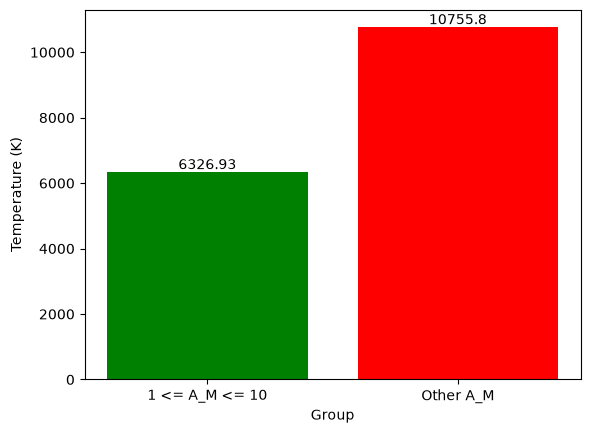

In [14]:
bars = plt.bar(
    ["1 <= A_M <= 10", "Other A_M"],
    [first_grupe_temperature, other_stars],
    color= ['green', 'red']
)

plt.xlabel("Group")
plt.ylabel("Temperature (K)")
plt.bar_label(bars)


## Conclusion

The most common spectral class and star type in the selected group are F and Type 3, respectively.

The selected stars do not have a higher average temperature than the remaining stars. However, this result may be influenced by the presence of brighter stars outside the selected group, which could increase the overall average temperature.
